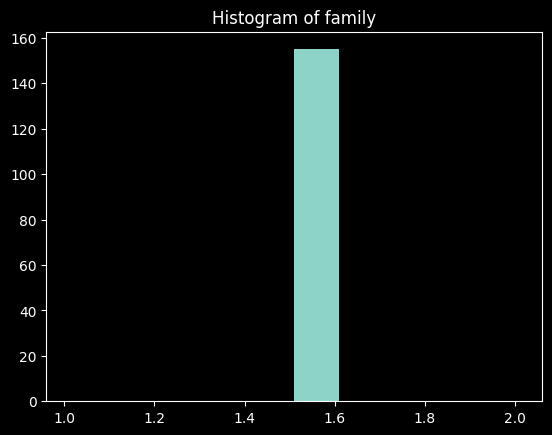

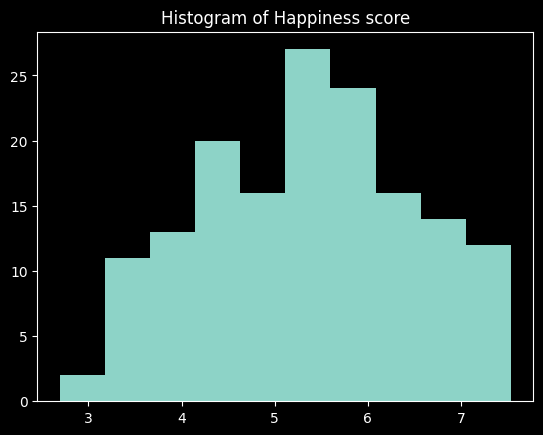

In [17]:

from matplotlib import pyplot as plt
import pandas as pd
df = pd.read_csv("data/v1_world-happiness-report-2017.csv",low_memory=False);
fam=df["Family"].tolist()
hapiness=df["Happiness.Score"].tolist()


def plotDataHistogram(x, variableName):
    n, bins, patches = plt.hist(x, 10)
    plt.title('Histogram of ' + variableName)
    plt.show()

plotDataHistogram(fam, 'family')
plotDataHistogram(hapiness, 'Happiness score')


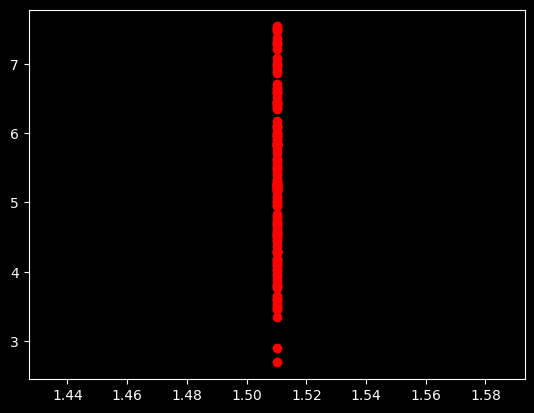

In [18]:
plt.plot(fam,hapiness, 'ro')

In [19]:
import random
from math import floor
lim=floor(len(fam)*0.8)
random.seed(47)

random.shuffle(fam)
random.shuffle(hapiness)
training_data=fam[:lim]
validation_data=fam[lim:]
training_label=hapiness[:lim]
validation_label=hapiness[lim:]

In [135]:
import random
import math
class Linear:
    def __init__(self):
        self.a=0.5
        self.b=0.5
    def predict(self,x):
        return self.a*x+self.b
    def __call__(self,x):
        return self.predict(x)
    def backward(self,x,rez):
        a=self.a
        b=self.b
        self.a -= (2*a*x**2+2*x*b-2*x*rez)*0.01
        self.b -= (2*a*x+2*b-2*rez)*0.01

a=training_data
b=training_label
l=Linear()
for k in range(10000):
    loss=0
    for i in range(len(a)):
        loss+=(l(a[i])-b[i])**2
        Linear.backward(l,a[i],b[i])
    loss_avg=loss/len(a)
print(loss)
print(loss_avg)

162.62068343576763
1.311457124481997


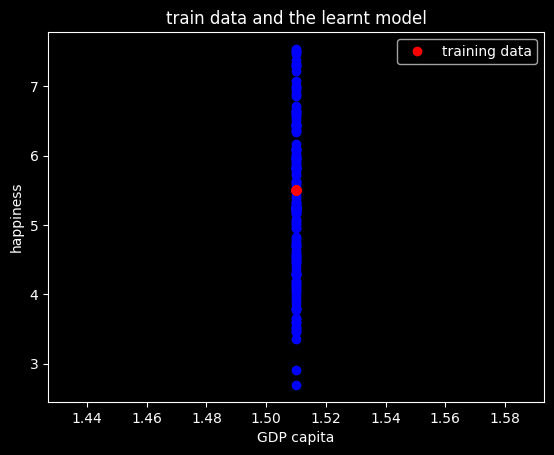

In [121]:
noOfPoints = 1000
xref = []
val = min(a)
step = (max(a) - min(a)) / noOfPoints
for i in range(1, noOfPoints):
    xref.append(val)
    val += step
yref = [l.b + l.a * el for el in xref]
plt.plot(fam,hapiness, 'bo')
plt.plot(training_data, [l(x) for x in training_data], 'ro', label='training data')
plt.title('train data and the learnt model')
plt.xlabel('GDP capita')
plt.ylabel('happiness')
plt.legend()
plt.show()

In [131]:
loss=0
for i in range(len(validation_data)-1):
    loss+=(Linear.predict(l,validation_data[i])-validation_label[i])**2
    print(Linear.predict(l,validation_data[i]))
avg_loss=loss/len(validation_data)
print(avg_loss)


5.502580444641313
5.502580444641313
5.502580444641313
5.502580444641313
5.502580444641313
5.502580444641313
5.502580444641313
5.502580444641313
5.502580444641313
5.502580444641313
5.502580444641313
5.502580444641313
5.502580444641313
5.502580444641313
5.502580444641313
5.502580444641313
5.502580444641313
5.502580444641313
5.502580444641313
5.502580444641313
5.502580444641313
5.502580444641313
5.502580444641313
5.502580444641313
5.502580444641313
5.502580444641313
5.502580444641313
5.502580444641313
5.502580444641313
5.502580444641313
1.335452263674891
